In [1]:
from escripts import eplots
from escripts import eMCMC
from escripts import edata

In [4]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['Bouwens+21', 'Donnan+24', r'Donnan+24 ultra high-$z$']
sorted_data = edata.get_sorted(file_names, data_labels)

In [5]:
params = eMCMC.build_param_data({'beta': {'fit': False, 'value': -1.49}, 'dbetadz': {'fit': False, 'value': 0.22}})
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [41]:
best_fit = [0.51, -0.02, 11.74, -0.04, -1.33, -0.12, 0.52, 0.23, -0.03, 0.67]
no_z_ev = [1.02, -0.02, 11.54, -0.01, -1.45, -0.16, 0.58, 0, -1.1, 0.79]
no_m_ev = [0.49, -0.02, 11.76, -0.04, -1.34, -0.12, 0.53, 0.24, 0, 0.67]
# low_sig = 

# UVLF for different models

# Fiducial vs. piecewise

In [12]:
params = eMCMC.build_param_data({})
UVLF_piecewise = eMCMC.UVLF(sorted_data, params)

In [10]:
fiducial = [0.49, -0.02, -1.49, 0.22, 11.76, -0.04, -1.34, -0.12, 0.53, 0.24, 0, 0.67]

chunked = [0.51, -0.02, 11.74, -0.04, -1.33, -0.12, [0.64, 0.67, 0.65, 0.69, 0.6, 0.69, 1.05, 1.46, 1.56], 0, 0, 0.3]

In [9]:
lowers = np.array([0.04, 0.03, 0.05, 0.07, 0.1, 0.12, 0.1, 0.08, 0.08])
uppers = np.array([0.04, 0.03, 0.03, 0.04, 0.06, 0.07, 0.05, 0.05, 0.05])

yerr = np.vstack((lowers, uppers))

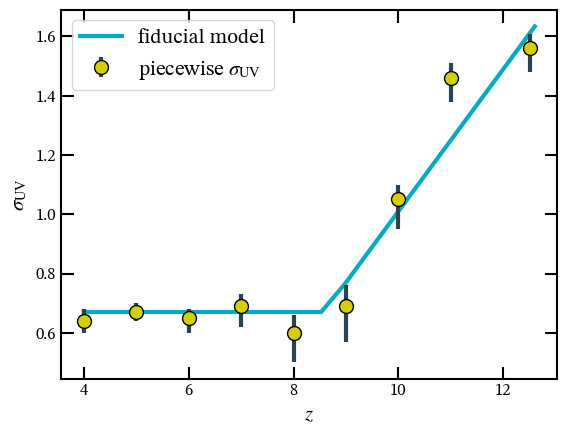

In [15]:
fig, ax = plt.subplots()
zs = np.linspace(4, 12.6, 20)
sig_lin = [UVLF_piecewise.time_evolution(fiducial, z)[-1][-1] for z in zs]
ax.plot(zs, sig_lin, color = eplots.turquoise, label = 'fiducial model')
ax.errorbar(UVLF_piecewise.zs, chunked[-4], fmt = 'o', color = eplots.yellow, yerr = yerr, markersize = 10, ecolor = eplots.navy, label = r'piecewise $\sigma_{\rm{UV}}$')

ax.set_ylabel(r'$\sigma_{\rm{UV}}$')
ax.set_xlabel(r'$z$')
ax.legend()

In [16]:
fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/fiducial_vs_piecewise.png', dpi = 200)

# Extend to higher $z$

In [51]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt', 
             '/Users/eb35267/Desktop/code/home/data/Donnan24_high_z.txt',
             '/Users/eb35267/Desktop/code/home/data/Kokorev+25.txt',
             '/Users/eb35267/Desktop/code/home/data/Weibel+25_upper_limits.txt']
data_labels = ['Bouwens+21', r'Donnan+24 ultra high-$z$','Kokorev+25', 'Weibel+25']
include = [True, False, False, False, False]
sorted_data = edata.get_sorted(file_names, data_labels, include_in_likelihood = include)

In [52]:
params = eMCMC.build_param_data({'beta': {'fit': False, 'value': -1.49}, 'dbetadz': {'fit': False, 'value': 0.22}})
UVLF_extended = eMCMC.UVLF(sorted_data, params)

In [56]:
importlib.reload(eplots)

/Users/eb35267/Desktop/code/home/escripts/eplots.py:624: SyntaxWarning: invalid escape sequence '\s'
  # HMF prior (normalized)


<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

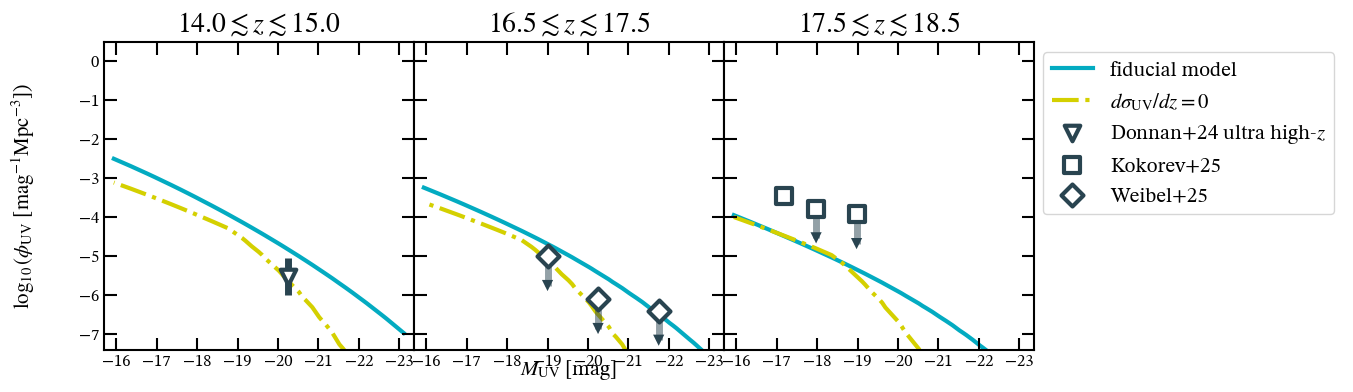

In [57]:
z_plot = [14.5, 17, 18]
ext_ev = eplots.evolving_UVLF_fit(UVLF_extended, plot_from_chain = False, comparison_fits = [no_m_ev, no_z_ev], 
                               comparison_labels = [r'fiducial model', r'$d\sigma_{\rm{UV}}/dz = 0$'], 
                               title = '', ncols = 4, z_plot = z_plot, show_chi2 = False)